### Human In the Loop

In [2]:
import os
from langchain.chat_models import init_chat_model


llm = init_chat_model('groq:openai/gpt-oss-20b')
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.12'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F01B524EC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F01B525940>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [3]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from typing_extensions import TypedDict , Annotated
from langgraph.graph import StateGraph , START , END ,add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition , ToolNode

from langgraph.types import Command , interrupt

class State(TypedDict):
    messages : Annotated[list , add_messages ]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)


graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,    
)
graph_builder.add_edge("tools", "chatbot")




In [4]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

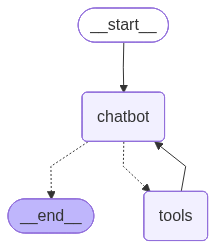

In [5]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [6]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_80192e86-f9f4-4aa2-8225-3a3dd96adf4d)
 Call ID: fc_80192e86-f9f4-4aa2-8225-3a3dd96adf4d
  Args:
    query: I need some expert guidance and assistance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_80192e86-f9f4-4aa2-8225-3a3dd96adf4d)
 Call ID: fc_80192e86-f9f4-4aa2-8225-3a3dd96adf4d
  Args:
    query: I need some expert guidance and assistance for building an AI agent.


In [7]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_80192e86-f9f4-4aa2-8225-3a3dd96adf4d)
 Call ID: fc_80192e86-f9f4-4aa2-8225-3a3dd96adf4d
  Args:
    query: I need some expert guidance and assistance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

Absolutely—let’s get you on the fast track to building a robust AI agent. Below is a quick primer on the most popular frameworks, a step‑by‑step outline for getting started, and some practical tips to keep your project scalable and maintainable.

---

## 1. Choose the Right Framework

| Framework | Strengths | Typical Use‑Case | Getting Started |
|-------